In [ ]:
# Task 3: Car Price Prediction with Machine Learning

## Objective

The objective of this project is to build a machine learning regression
model that predicts the selling price of a used car based on features
such as brand, car age, mileage, fuel type, transmission, and other
available car specifications.

The project includes:

- Data cleaning and preprocessing
- Feature engineering
- Exploratory Data Analysis (EDA)
- Categorical variable encoding
- Feature correlation analysis
- Training multiple regression models
- Model evaluation using MAE, RMSE, and R²
- Feature importance analysis

In [10]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display plots inside the notebook
%matplotlib inline

In [11]:
# Upload the dataset

from google.colab import files

uploaded = files.upload()

Saving car_price_prediction_.csv to car_price_prediction_ (1).csv


In [13]:
# Load the car price dataset

df = pd.read_csv("/content/car_price_prediction_.csv")

# Display the first five rows
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [14]:
# Display the number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (2500, 10)


In [15]:
# Display information about columns, data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [16]:
# Check for missing values in each column

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64


In [17]:
# Display statistical summary of numerical columns

df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [18]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [20]:
# Remove unnecessary spaces and standardize categorical values

categorical_columns = [
    "Brand",
    "Fuel Type",
    "Transmission",
    "Condition",
    "Model"
]

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip()

# Standardize text capitalization
df["Brand"] = df["Brand"].str.title()
df["Fuel Type"] = df["Fuel Type"].str.title()
df["Transmission"] = df["Transmission"].str.title()
df["Condition"] = df["Condition"].str.title()
df["Model"] = df["Model"].str.title()

print("Categorical values cleaned successfully.")

Categorical values cleaned successfully.


In [21]:
# Display unique values for important categorical columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 Brand
['Tesla' 'Bmw' 'Audi' 'Ford' 'Honda' 'Mercedes' 'Toyota']

 Fuel Type
['Petrol' 'Electric' 'Diesel' 'Hybrid']

 Transmission
['Manual' 'Automatic']

 Condition
['New' 'Used' 'Like New']

 Model
['Model X' '5 Series' 'A4' 'Model Y' 'Mustang' 'Q7' 'Q5' 'Civic'
 'Explorer' 'Model 3' 'Fiesta' 'X3' 'Gla' 'A3' 'X5' 'C-Class' 'E-Class'
 'Cr-V' 'Camry' 'Accord' 'Glc' 'Corolla' 'Fit' 'Model S' 'Prius'
 '3 Series' 'Rav4' 'Focus']


In [23]:
# Calculate car age from the Year column

current_year = 2026

df["Car Age"] = current_year - df["Year"]

# Display the result
df[["Year", "Car Age"]].head()

,Year,Car Age
0,2016,10
1,2018,8
2,2013,13
3,2011,15
4,2009,17


In [25]:
# Display the updated dataset

df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,Car Age
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X,10
1,2,Bmw,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series,8
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4,13
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y,15
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang,17


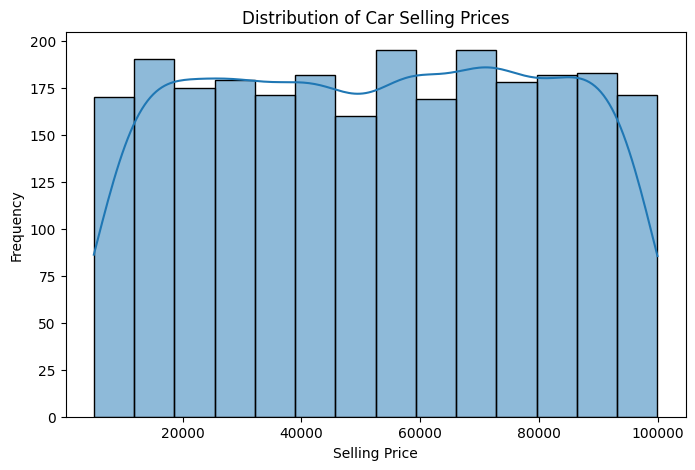

In [26]:
# Plot the distribution of car selling prices

plt.figure(figsize=(8, 5))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

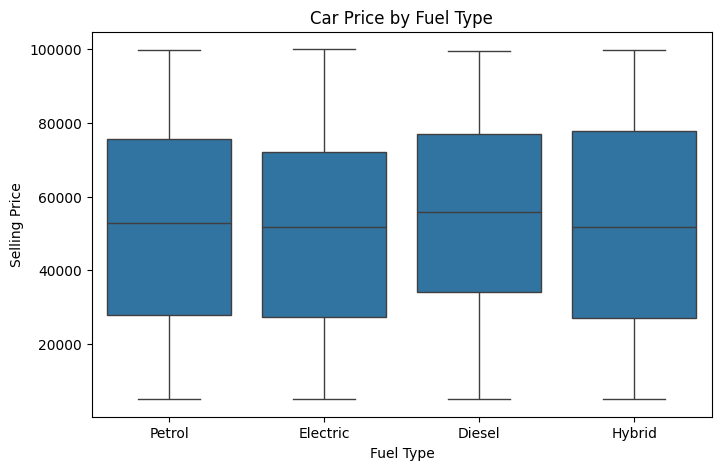

In [27]:
# Compare car prices across different fuel types

plt.figure(figsize=(8, 5))

sns.boxplot(x="Fuel Type", y="Price", data=df)

plt.title("Car Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

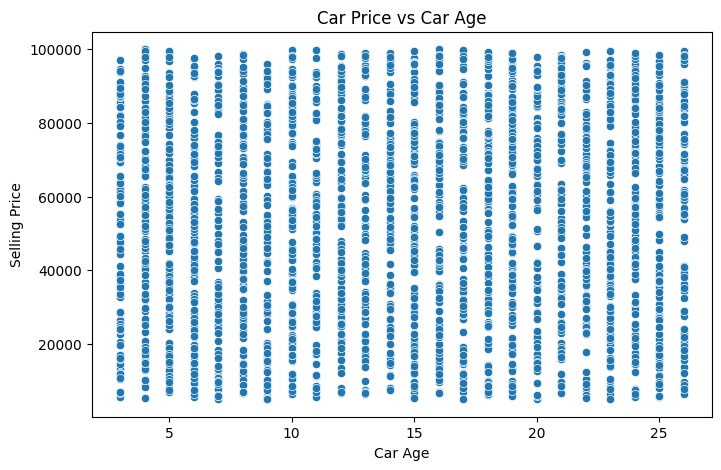

In [28]:
# Plot the relationship between car age and selling price

plt.figure(figsize=(8, 5))

sns.scatterplot(x="Car Age", y="Price", data=df)

plt.title("Car Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

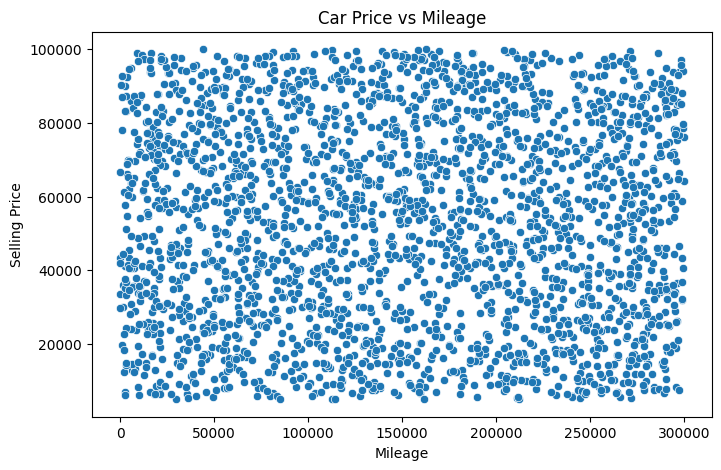

In [30]:
# Plot the relationship between mileage and selling price

plt.figure(figsize=(8, 5))

sns.scatterplot(x="Mileage", y="Price", data=df)

plt.title("Car Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Selling Price")

plt.show()

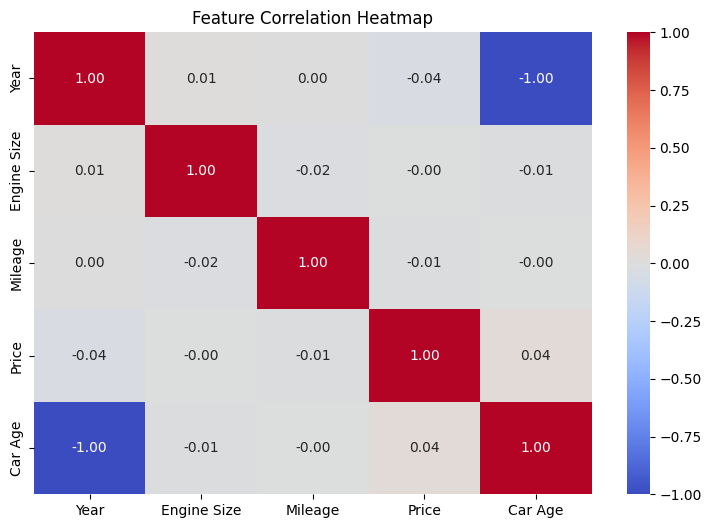

In [32]:
# Select numerical columns for correlation analysis

numerical_columns = [
    "Year",
    "Engine Size",
    "Mileage",
    "Price",
    "Car Age"
]

correlation_matrix = df[numerical_columns].corr()

# Plot correlation heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [34]:
# Define the target variable

y = df["Price"]

# Select features for prediction
X = df[
    [
        "Brand",
        "Car Age",
        "Engine Size",
        "Fuel Type",
        "Transmission",
        "Mileage",
        "Condition",
        "Model"
    ]
]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Brand  Car Age  Engine Size Fuel Type Transmission  Mileage Condition  \
0  Tesla       10          2.3    Petrol       Manual   114832       New   
1    Bmw        8          4.4  Electric       Manual   143190      Used   
2   Audi       13          4.5  Electric       Manual   181601       New   
3  Tesla       15          4.1    Diesel    Automatic    68682       New   
4   Ford       17          2.6    Diesel       Manual   223009  Like New   

      Model  
0   Model X  
1  5 Series  
2        A4  
3   Model Y  
4   Mustang  

Target:
0    26613.92
1    14679.61
2    44402.61
3    86374.33
4    73577.10
Name: Price, dtype: float64


In [36]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2000, 8)
Testing data: (500, 8)


In [38]:
# Define categorical and numerical columns

categorical_features = [
    "Brand",
    "Fuel Type",
    "Transmission",
    "Condition",
    "Model"
]

numerical_features = [
    "Car Age",
    "Engine Size",
    "Mileage"
]

In [40]:
# One-Hot Encode categorical features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [42]:
# Create Linear Regression pipeline

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [44]:
# Make predictions using Linear Regression

linear_predictions = linear_model.predict(X_test)

print("First 10 predictions:")
print(linear_predictions[:10])

First 10 predictions:
[52621.4229335  51362.56790508 52401.21524492 53245.32548145
 51889.08307213 50964.28988462 51605.73151604 52044.19437466
 53169.63614975 52543.86269866]


In [46]:
# Calculate evaluation metrics

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Results
-------------------------
MAE : 23742.52299078104
RMSE: 27526.01612897458
R²  : -0.0001692707868707899


In [48]:
# Create Random Forest Regression pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

# Train the Random Forest model
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


In [50]:
# Make predictions using Random Forest

rf_predictions = random_forest_model.predict(X_test)

print("First 10 predictions:")
print(rf_predictions[:10])

First 10 predictions:
[63588.03785 43808.62795 48861.95205 49605.5958  47103.31705 46419.04285
 53789.1278  47055.69035 55266.44425 56679.09285]


In [52]:
# Calculate evaluation metrics

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 24544.3956448
RMSE: 28467.434614915877
R²  : -0.06975284645806323


In [54]:
# Create a comparison table

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R² Score": [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,23742.522991,27526.016129,-0.000169
1,Random Forest,24544.395645,28467.434615,-0.069753


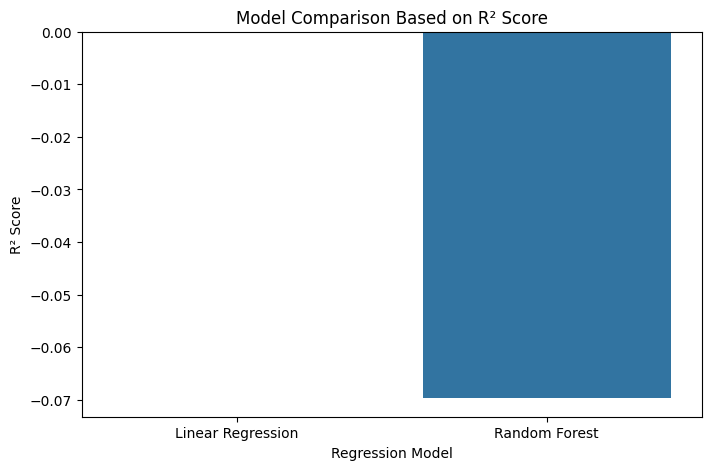

In [56]:
# Plot R² scores for both models

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="R² Score",
    data=results
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")

plt.show()

In [58]:
# Select the model with the highest R² score

if rf_r2 > linear_r2:
    best_model = random_forest_model
    best_predictions = rf_predictions
    best_model_name = "Random Forest"
    best_r2 = rf_r2
else:
    best_model = linear_model
    best_predictions = linear_predictions
    best_model_name = "Linear Regression"
    best_r2 = linear_r2

print("Best Performing Model:", best_model_name)
print("Best R² Score:", best_r2)

Best Performing Model: Linear Regression
Best R² Score: -0.0001692707868707899


In [60]:
# Feature importance for Random Forest

rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_model = random_forest_model.named_steps["model"]

# Get encoded feature names
encoded_features = rf_preprocessor.named_transformers_[
    "categorical"
].get_feature_names_out(categorical_features)

# Combine categorical and numerical feature names
feature_names = np.concatenate([
    encoded_features,
    numerical_features
])

# Get feature importance values
importances = rf_model.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
46,Mileage,0.240809
45,Engine Size,0.169033
44,Car Age,0.136129
13,Condition_Like New,0.018880
9,Fuel Type_Hybrid,0.018633
15,Condition_Used,0.018607
14,Condition_New,0.018187
10,Fuel Type_Petrol,0.017521
8,Fuel Type_Electric,0.017235
7,Fuel Type_Diesel,0.016592


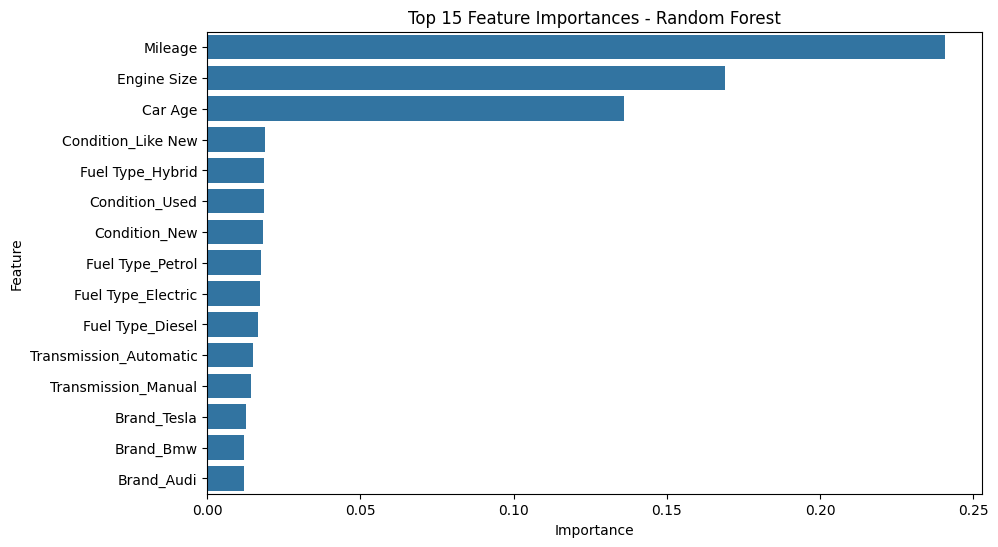

In [62]:
# Plot the top 15 important features

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

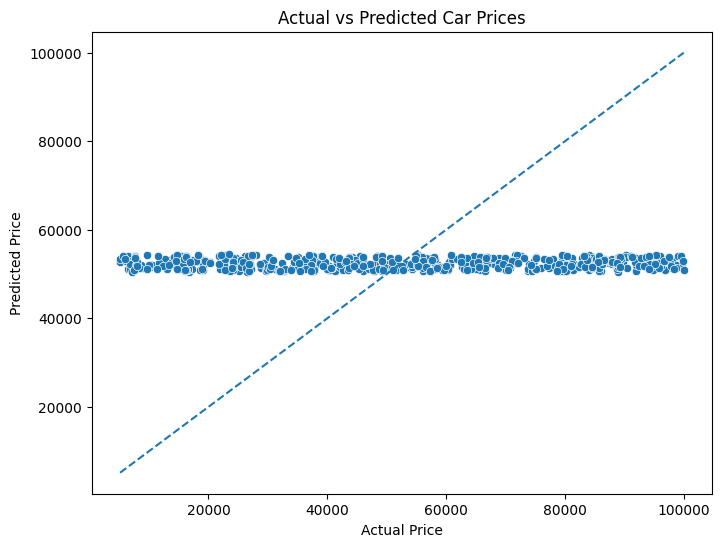

In [64]:
# Compare actual and predicted prices

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)

# Reference line
min_price = min(y_test.min(), best_predictions.min())
max_price = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [66]:
# Display final model performance

print("Final Model Performance")
print("=======================")

print("Best Model:", best_model_name)
print("MAE:", mean_absolute_error(y_test, best_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_predictions)))
print("R² Score:", r2_score(y_test, best_predictions))

Final Model Performance
Best Model: Linear Regression
MAE: 23742.52299078104
RMSE: 27526.01612897458
R² Score: -0.0001692707868707899


In [ ]:
# Conclusion

In this project, a machine learning regression system was developed
to predict used car selling prices.

The dataset was cleaned by checking missing values, removing duplicate
records, and standardizing categorical values.

Feature engineering was performed by calculating car age from the
manufacturing year.

Exploratory Data Analysis was conducted using price distributions,
fuel-type box plots, car-age scatter plots, and a correlation heatmap.

Categorical features were converted into numerical representations
using One-Hot Encoding.

Two regression models were trained:

- Linear Regression
- Random Forest Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the highest R² score was selected as the best-performing
model. Feature importance analysis was then performed to identify the
features that contributed most to car price prediction.

Overall, the project demonstrates how machine learning can be used
to estimate used car prices from vehicle characteristics.